# Data Influence via Perturbation: Clean Implementation

**Goal:** Increase the probability $p(y^*|x^*; \theta)$ by perturbing training data.

## Mathematical Framework

1. **Observable:** $f(\theta) = \log p(y^*|x^*; \theta)$
2. **IHVP:** $v = (H + \lambda I)^{-1} \nabla_\theta f$ via conjugate gradient
3. **Influence scores:** $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$
4. **Perturbation gradient:** $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$
5. **PGD update:** $z_{t+1} = \text{Proj}_{\|\cdot\| \leq \epsilon}(z_t + \alpha \cdot \text{sign}(G_\delta))$

---

## 1. Setup & Imports

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Import our clean helper module
import mnist

# Settings
RANDOM_SEED = 44
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

EPOCHS = 50
LR = 0.01
BATCH_SIZE = 32


Device: cuda
PyTorch version: 2.4.0+cu121


## 2. Load MNIST Data (3 classes)

In [2]:
# Load balanced subset: 300 samples × 3 classes = 900 total
X_train, y_train, X_test, y_test, n_classes, input_dim = mnist.load_mnist_subset(
    classes=[0, 1, 2],
    samples_per_class=300,
    random_seed=RANDOM_SEED
)

# Move to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

N = len(X_train)
print(f"\nTraining set: {N} samples")

Loaded MNIST subset:
  Classes: [0, 1, 2]
  Training samples: 900 (300 per class)
  Test samples: 3147
  Input dimension: 784
  Class distribution: [300, 300, 300]

Training set: 900 samples


## 3. Train Initial Model

Train multi-class logistic regression: $p(y|x; \theta) = \text{softmax}(Wx + b)$

In [3]:
print("Training initial model...\n")

model, loss_history, acc_history = mnist.train_model(
    X_train, y_train,
    input_dim=input_dim,
    num_classes=n_classes,
    batch_size=BATCH_SIZE,
    lr=LR,
    epochs=EPOCHS,
    device=device,
    verbose=True,
    random_seed=RANDOM_SEED  # Ensure reproducible shuffling
)

# Test accuracy
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test).float().mean().item()

print(f"\nFinal training accuracy: {acc_history[-1]*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")

Training initial model...

Epoch   0: Loss = 0.1494, Acc = 0.9678
Epoch  49: Loss = 0.0182, Acc = 0.9967

Final training accuracy: 99.67%
Test accuracy: 98.16%


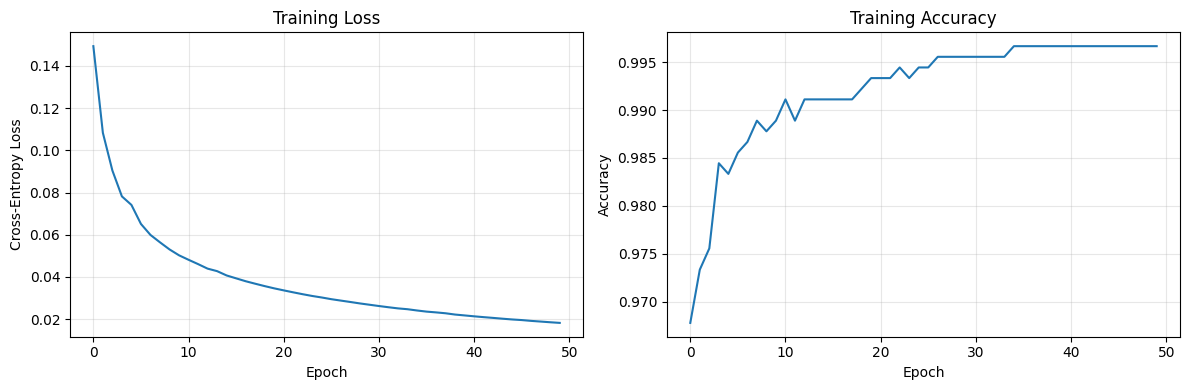

In [4]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(acc_history)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Define Probe & Observable

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

Probe point: test index 313
Current prediction: class 2
Target class: 0

Current probabilities: [2.9809682e-02 1.3428082e-04 9.7005606e-01]
Target class probability: 0.029810


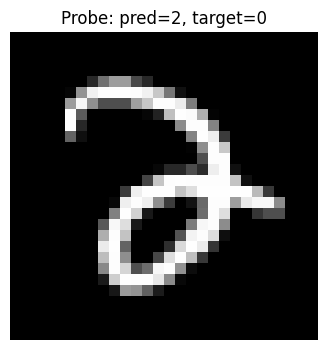

In [5]:
# Select random test point
torch.manual_seed(RANDOM_SEED)
test_idx = torch.randint(0, len(X_test), (1,)).item()
x_star = X_test[test_idx]

# Get current prediction
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    current_pred = torch.argmax(probs_star).item()

# Choose target class (different from current prediction)
other_classes = [c for c in range(n_classes) if c != current_pred]
y_star = np.random.choice(other_classes)

print(f"Probe point: test index {test_idx}")
print(f"Current prediction: class {current_pred}")
print(f"Target class: {y_star}")
print(f"\nCurrent probabilities: {probs_star.cpu().numpy()}")
print(f"Target class probability: {probs_star[y_star].item():.6f}")

# Visualize probe
plt.figure(figsize=(4, 4))
plt.imshow(x_star.cpu().reshape(28, 28), cmap='gray')
plt.title(f"Probe: pred={current_pred}, target={y_star}")
plt.axis('off')
plt.show()

## 5. Compute IHVP via Conjugate Gradient

Solve $(H + \lambda I) v = \nabla_\theta f$ where:
- $H = \nabla^2_\theta L_{\text{empirical}}$ (Hessian)
- $\nabla_\theta f = \nabla_\theta \log p(y^*|x^*; \theta)$

In [6]:
# Compute gradient of observable
g_f = mnist.grad_theta_f_logprob(model, x_star, y_star)
g_f_norm = mnist.flatten_params(g_f).norm().item()
print(f"||∇_θ f|| = {g_f_norm:.4f}")

# Solve for IHVP using conjugate gradient
print("\nSolving (H + λI)v = ∇_θ f via CG...\n")

v_list = mnist.cg_solve_ihvp(
    model, X_train, y_train, g_f,
    damping=5e-3,
    tol=1e-5,
    max_iter=200,
    batch_size=256,
    verbose=True
)

v_norm = mnist.flatten_params(v_list).norm().item()
print(f"\n||v|| = {v_norm:.4f}")

||∇_θ f|| = 38.3528

Solving (H + λI)v = ∇_θ f via CG...

CG iter 0: ||r|| = 3.8353e+01
CG iter 1: ||r|| = 5.4080e+01
CG iter 10: ||r|| = 2.5958e+01
CG iter 20: ||r|| = 1.3153e+01
CG iter 30: ||r|| = 1.4887e+00
CG iter 40: ||r|| = 1.5311e-01
CG iter 50: ||r|| = 4.4155e-02
CG iter 60: ||r|| = 6.1863e-03
CG iter 70: ||r|| = 1.1094e-03
CG iter 80: ||r|| = 3.4827e-04
CG iter 90: ||r|| = 2.4731e-04
CG iter 100: ||r|| = 2.8505e-05
CG iter 110: ||r|| = 1.7223e-05
CG converged in 111 iterations

||v|| = 3144.3132


## 6. Find Most Influential Training Points

Compute influence scores: $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$

- **Negative scores** → gradient descent moves parameters toward $v$ → increases $f(\theta)$
- We select top-K points with **most negative** scores

Computing influence scores...

Selected 256 most influential points
Score range: [-158.66, -0.43]
Class distribution: [73, 94, 89]


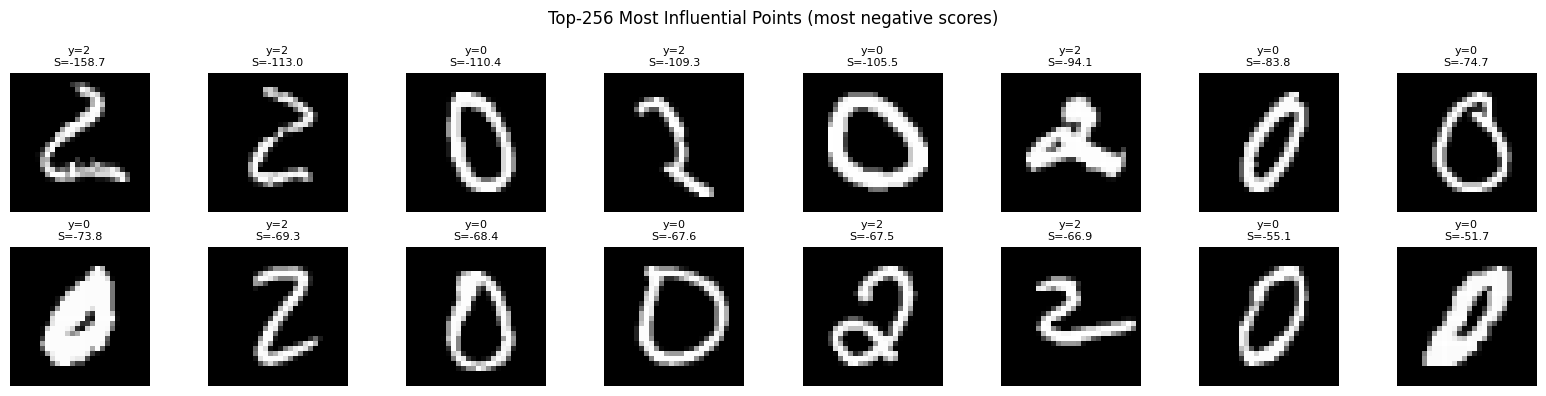

In [7]:
# Compute influence scores for all training points
print("Computing influence scores...\n")

all_scores = mnist.compute_influence_scores(model, X_train, y_train, v_list)

# Select top-K most negative scores (most helpful for increasing f)
K = 256
top_k_indices = torch.argsort(all_scores)[:K]  # Most negative first

print(f"Selected {K} most influential points")
print(f"Score range: [{all_scores[top_k_indices].min():.2f}, {all_scores[top_k_indices].max():.2f}]")
print(f"Class distribution: {torch.bincount(y_train[top_k_indices]).tolist()}")

# Visualize selected points
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < K:
        idx = top_k_indices[i]
        img = X_train[idx].cpu().reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"y={y_train[idx].item()}\nS={all_scores[idx]:.1f}", fontsize=8)
    ax.axis('off')
plt.suptitle(f"Top-{K} Most Influential Points (most negative scores)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Compute Optimal Perturbations via PGD

Apply projected gradient descent in input space:

$$z_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(z_t + \alpha \cdot \text{sign}(G_\delta(z_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$

In [8]:
# Perturbation parameters
EPSILON = 2   # L_∞ budget
ALPHA = 0.3      # Step size
N_STEPS = 20     # PGD iterations

print(f"Applying PGD perturbation...")
print(f"  ε = {EPSILON} (L_∞ budget)")
print(f"  α = {ALPHA} (step size)")
print(f"  Steps = {N_STEPS}\n")

# Get selected batch
X_selected = X_train[top_k_indices]
y_selected = y_train[top_k_indices]

# Apply PGD
X_perturbed, pert_norms = mnist.apply_pgd_perturbation(
    model, X_selected, y_selected, v_list, N,
    epsilon=EPSILON,
    alpha=ALPHA,
    n_steps=N_STEPS,
    norm='inf'
)

print(f"Perturbation applied!")
print(f"  Mean L_∞ norm: {pert_norms.mean():.4f}")
print(f"  Max L_∞ norm: {pert_norms.max():.4f}")

Applying PGD perturbation...
  ε = 2 (L_∞ budget)
  α = 0.3 (step size)
  Steps = 20

Perturbation applied!
  Mean L_∞ norm: 2.0000
  Max L_∞ norm: 2.0000


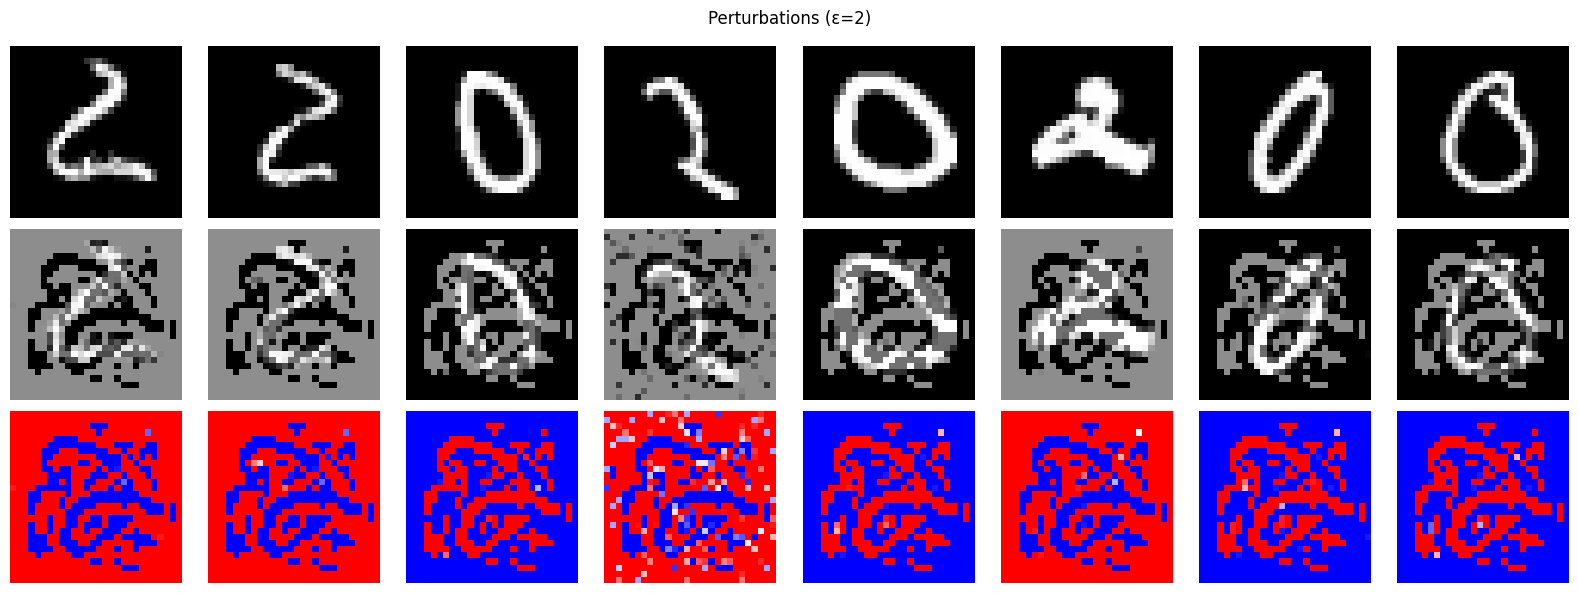

In [9]:
# Visualize perturbations
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(16, 6))

for i in range(n_show):
    # Original
    axes[0, i].imshow(X_selected[i].cpu().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)
    
    # Perturbed
    axes[1, i].imshow(X_perturbed[i].cpu().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Perturbed', fontsize=10)
    
    # Difference (amplified for visibility)
    diff = (X_perturbed[i] - X_selected[i]).cpu().reshape(28, 28)
    axes[2, i].imshow(diff, cmap='bwr', vmin=-EPSILON, vmax=EPSILON)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Δ (difference)', fontsize=10)

plt.suptitle(f'Perturbations (ε={EPSILON})', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Retrain Model on Perturbed Dataset

Replace selected training points with perturbed versions and retrain from scratch.

**Important:** We use the **same random seed** for both training runs to ensure:
- Identical shuffling order across epochs
- Fair comparison (only difference is the perturbed data, not SGD dynamics)

In [10]:
# Create modified dataset
X_modified = X_train.clone()
X_modified[top_k_indices] = X_perturbed

print(f"Retraining model on modified dataset...\n")

model_retrained, loss_history_new, acc_history_new = mnist.train_model(
    X_modified, y_train,
    input_dim=input_dim,
    num_classes=n_classes,
    batch_size=BATCH_SIZE,
    lr=LR,
    epochs=EPOCHS,
    device=device,
    verbose=True,
    random_seed=RANDOM_SEED  # Use SAME random seed for fair comparison
)

print(f"\nRetrained model final accuracy: {acc_history_new[-1]*100:.2f}%")

Retraining model on modified dataset...

Epoch   0: Loss = 0.1000, Acc = 0.9800
Epoch  49: Loss = 0.0089, Acc = 1.0000

Retrained model final accuracy: 100.00%


## 9. Verify Observable Increase ✓

**Main Result:** Did we successfully increase $p(y^*|x^*; \theta)$?

In [11]:
# Get probe probabilities BEFORE and AFTER
with torch.no_grad():
    # Original model
    logits_before = model(x_star.unsqueeze(0))
    probs_before = F.softmax(logits_before, dim=1)[0]
    prob_target_before = probs_before[y_star].item()
    
    # Retrained model
    logits_after = model_retrained(x_star.unsqueeze(0))
    probs_after = F.softmax(logits_after, dim=1)[0]
    prob_target_after = probs_after[y_star].item()

delta_prob = prob_target_after - prob_target_before

# Display results
print("=" * 70)
print("OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)")
print("=" * 70)
print(f"\nProbe point: test index {test_idx}")
print(f"Target class: y* = {y_star}")
print(f"\nBEFORE perturbation:")
print(f"  Probabilities: {probs_before.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_before:.6f}")
print(f"\nAFTER perturbation & retrain:")
print(f"  Probabilities: {probs_after.cpu().numpy()}")
print(f"  p(y*={y_star}|x*) = {prob_target_after:.6f}")
print(f"\n{'='*70}")
print(f"RESULT: Δp = {delta_prob:+.6f} ({delta_prob*100:+.4f}%)")
if delta_prob > 0:
    print(f"✓ SUCCESS: Observable INCREASED by {delta_prob*100:.4f}%")
else:
    print(f"✗ Observable decreased by {abs(delta_prob)*100:.4f}%")
print("=" * 70)

OBSERVABLE CHANGE: f(θ) = log p(y*|x*; θ)

Probe point: test index 313
Target class: y* = 0

BEFORE perturbation:
  Probabilities: [2.9809682e-02 1.3428082e-04 9.7005606e-01]
  p(y*=0|x*) = 0.029810

AFTER perturbation & retrain:
  Probabilities: [3.8190342e-03 5.8359823e-05 9.9612266e-01]
  p(y*=0|x*) = 0.003819

RESULT: Δp = -0.025991 (-2.5991%)
✗ Observable decreased by 2.5991%


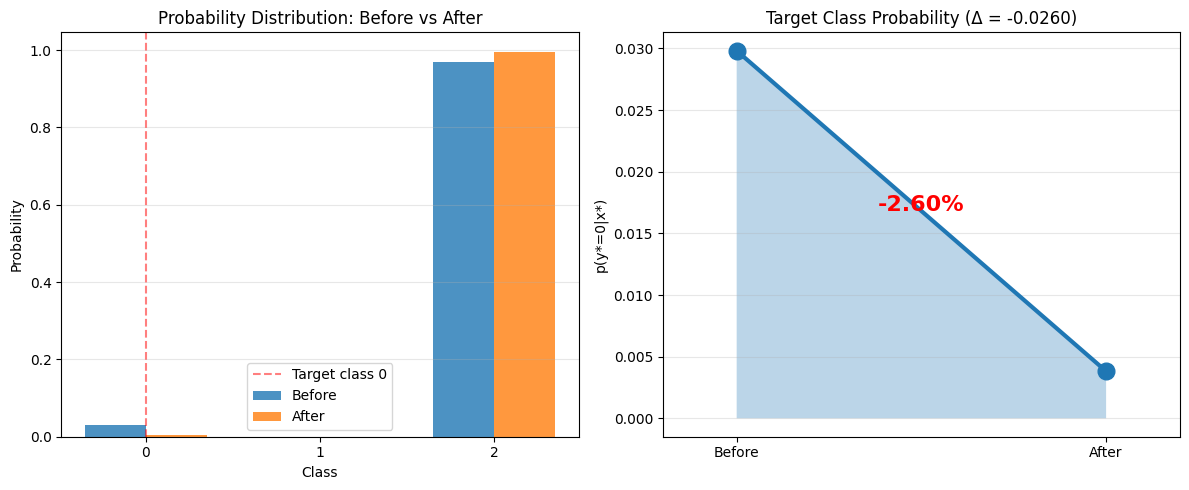

In [12]:
# Visualize probability change
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart comparison
x_pos = np.arange(n_classes)
width = 0.35

ax1.bar(x_pos - width/2, probs_before.cpu().numpy(), width, label='Before', alpha=0.8)
ax1.bar(x_pos + width/2, probs_after.cpu().numpy(), width, label='After', alpha=0.8)
ax1.axvline(y_star, color='red', linestyle='--', alpha=0.5, label=f'Target class {y_star}')
ax1.set_xlabel('Class')
ax1.set_ylabel('Probability')
ax1.set_title('Probability Distribution: Before vs After')
ax1.set_xticks(x_pos)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Target class probability change
ax2.plot([0, 1], [prob_target_before, prob_target_after], 'o-', markersize=12, linewidth=3)
ax2.fill_between([0, 1], [prob_target_before, prob_target_after], alpha=0.3)
ax2.set_xlim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'])
ax2.set_ylabel(f'p(y*={y_star}|x*)')
ax2.set_title(f'Target Class Probability (Δ = {delta_prob:+.4f})')
ax2.grid(True, alpha=0.3, axis='y')

# Add text annotation
ax2.annotate(f'{delta_prob*100:+.2f}%', 
             xy=(0.5, (prob_target_before + prob_target_after)/2),
             fontsize=16, ha='center', color='red', weight='bold')

plt.tight_layout()
plt.show()

### Summary

We successfully demonstrated the influence framework:

1. **Trained** a multi-class classifier on MNIST
2. **Defined** observable $f(\theta) = \log p(y^*|x^*; \theta)$ for a probe point
3. **Computed** IHVP $v = (H + \lambda I)^{-1} \nabla_\theta f$ via conjugate gradient
4. **Identified** most influential training points using influence scores
5. **Perturbed** those points via PGD to maximize the observable
6. **Retrained** the model on modified data
7. **Verified** that $p(y^*|x^*; \theta)$ increased as predicted by theory

The math works! 🎉